# Estimacion Posterior para SIR modificado

In [1]:
import datetime
from functools import partial

import numpy as np
import pandas as pd
from scipy.special import expit
import seaborn as sns

import bayesflow.diagnostics as diag
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.networks import InvertibleNetwork, SequenceNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator
from bayesflow.trainers import Trainer
import random

import matplotlib.pyplot as plt


c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\bayesflow\trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
RNG = np.random.default_rng(2023)

## Defining the Generative Model <a class="anchor" id="defining_the_generative"></a>


Las ecuaciones que gobiernan el modelo son:

\begin{cases}
\frac{dS}{dt} = - (1 - r(I(t-\tau)/N)) \frac{\beta S(t)I(t)}{N} \\\\
\frac{dI}{dt} = (1 - r(I(t-\tau)/N)) \frac{\beta S(t)I(t)}{N} - \gamma I(t) \\\\
\frac{dR}{dt} = \gamma I(t)
\end{cases}

Donde:

- $\beta$ es la tasa de transmisión de la infección.
- $\gamma$ es la tasa de recuperación.
- $N = S + I + R$ es la población total.
- $r(I(t))$ es el factor de respuesta de miedo, definido como:

\begin{equation}
r(I(t-\tau)/N) = \frac{1}{1 + e^{-k(I(t-\tau)/N - c)}}
\end{equation}




### Prior <a class="anchor" id="prior"></a>


In [3]:
#beta = 0.5
#gamma = 1/7
def model_prior():
    """Genera una muestra aleatoria del prior conjunto."""

    k = np.random.randint(50,1000, size=1)[0]
    c = 100000*(np.random.uniform(0.0025,0.0075, size=1)[0])
    tau = np.random.randint(2,8, size=1)[0]#7
    beta = (np.random.uniform(0.3,0.6, size=1)[0])#0.65
    gamma = (np.random.uniform(0.1,0.3, size=1)[0])#0.25
    return np.array([k,c,beta,gamma,tau])


    #k,c,beta,gamma,tau=[1000, 0.002*100000, 0.4, 0.2, 5]


#print(gamma)

In [4]:
prior = Prior(prior_fun=model_prior, param_names=[ r"$k$",r"$c$", r"$\beta$",r"$\gamma$",r"$\tau$"])

During training, we will also standardize the prior draws, that is, ensure zero location and unit scale. We will do this purely for technical reasons - neural networks like scaled values. In addition, our current prior ranges differ vastly, so each parameter axis may contribute disproportionately to the loss function.

Here, we will use the `estimate_means_and_stds()` method of a `Prior` instance, which will estimate the prior means and standard deviations from random draws. We could have also just taken the analytic means and standard deviations, but these may not be available in all settings (e.g., implicit priors).

<strong>Caution:</strong> Make sure you have a seed or you set a seed whenever you are doing Monte Carlo estimation, since your results might differ slightly due to the empirical variation of the estimates!

In [5]:
# Recalculamos las medias y desviaciones estándar del prior
prior_means, prior_stds = prior.estimate_means_and_stds()

print(prior_means)
print(prior_stds)

[[5.18246000e+02 4.97262402e+02 4.54831193e-01 2.02262488e-01
  4.51500000e+00]]
[[2.78240650e+02 1.45333953e+02 8.78183281e-02 5.81922469e-02
  1.72416581e+00]]


### Simulator (Implicit Likelihood Function) <a class="anchor" id="simulator__implicit_likelihood"></a>


In [ ]:
from scipy.stats import nbinom

def scale_I(I_array, scale_range=0.1):
    factor = 1 + np.random.uniform(-scale_range, scale_range)
    return I_array * factor

def SIR_with_behavior(params,T,N, eps=1e-5):
    """Simula el modelo SIR con k y c."""
    k,c,beta,gamma,tau = params
    c=c/100000
    I0=np.random.randint(1000,1300, size=1)[0]
    #print(I0)
    # Redondea I0 para que sea un entero
    # Condiciones iniciales
    S, I, R = [N - I0], [I0], [0]
    I_t_tau  = np.repeat(I0,np.round(tau))
    # Simulamos T pasos de tiempo
    for t in range(T-1):
        # Valores actuales
        S_t, I_t, R_t = S[-1], I[-1], R[-1]

        

        # Calcular r(I(t)) 
        # usando una sigmoide estable
        x = k * (I_t_tau[t]/N - c)
        r_I = expit(x)

        nuevas_infecciones = (1 - r_I) * beta * S_t * I_t / N

        # Ecuaciones SIR
        dS = -nuevas_infecciones
        dI = nuevas_infecciones - gamma * I_t
        dR = gamma * I_t
  
        # Actualizamos las variables
        S_next = S_t + dS
        I_next = I_t + dI#*factor
        R_next = R_t + dR

        # Agregamos los nuevos valores
        S.append(S_next)
        I.append(I_next)
        R.append(R_next)
        I_t_tau=np.append(I_t_tau,I_next)
    I_array = np.array(I)[:, np.newaxis]
    
    #I_array = I_array * factor

    return I_array  # Forma (T+1, 1)


In [ ]:
import numpy as np

283.22041015745594

As you can see, in addition to the parameters, our simulator requires two further arguments: the total population size $N$ and the time horizon $T$. These are quantities over which we can amortize (i.e., context variables), but for this example, we will just use the population of Germany and the first two weeks of the pandemics (i.e., $T=14$), in the same vein as https://www.science.org/doi/10.1126/science.abb9789.

### Loading Real Data <a class="anchor" id="loading_real_data"></a>

Influenza USA

We then collect the context and real data into a Python dictionary for convenience.

In [ ]:
config = {"T": 50, "N": 1000000}#, "obs_data": load_data()} # 50 semanas y población de 1.000.000
config['N']=int(config['N'])

c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


6663.760154509513
3182.5298374526087
[500, 500.0, 0.6, 0.2, 5]


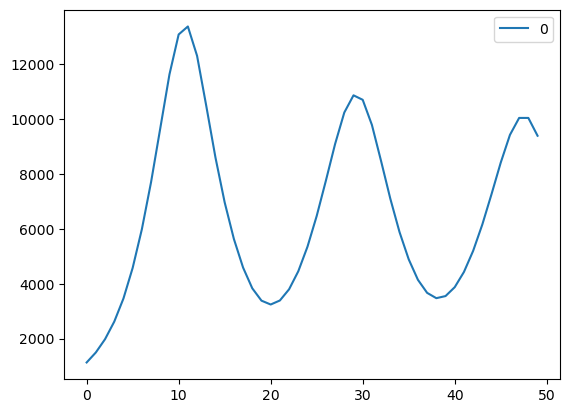

In [ ]:
# Ejemplos de previas y caso a simular

k,c,beta,gamma,tau=model_prior()
k,c,beta,gamma,tau=[500, 0.005*100000, 0.6, 0.2, 5]
S=SIR_with_behavior([k,c,beta,gamma,tau], T=config['T'],N=1000000, eps=1e-5)


# Graficar ambas series en la misma gráfica
sns.lineplot(data=S)
print(np.mean(S))
print(np.std(S))
print([k,c,beta,gamma,tau])

Since we won't vary the context variables during training, we can also define our simulator with fixed keyword arguments with the help of the `partial` function:

In [10]:
simulator = Simulator(simulator_fun=partial(SIR_with_behavior, T=config["T"], N=config["N"]))

Thus, whenever we call the `simulator` object, it will always use the keyword arguments provided to the `partial` function. Also, pay attention that we are passing the simulator function as a `simulator_fun` argument. A `Simulator` instance can also be initialized with a `batched_simulator_fun`, which implies that the simulator works on multiple (batched), instead of single, random draws from the prior.

### Generative Model <a class="anchor" id="generative_model"></a>

We now connect the prior and the simulator through the `GenerativeModel` wrapper:

In [11]:
model = GenerativeModel(prior, simulator, name="SIR_with_behavior_model")

INFO:root:Performing 2 pilot runs with the SIR_with_behavior_model model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 5)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 50, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


## Prior Checking <a class="anchor" id="prior_checking"></a>

Any principled Bayesian workflow requires some prior predictive or prior pushforward checks to ensure that the prior specification is consistent with domain expertise (see https://betanalpha.github.io/assets/case_studies/principled_bayesian_workflow.html). The BayesFlow library provides some rudimentary visual tools for performing prior checking. For instance, we can visually inspect the joint prior in the form of bivariate plots:

c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\cpasquier\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

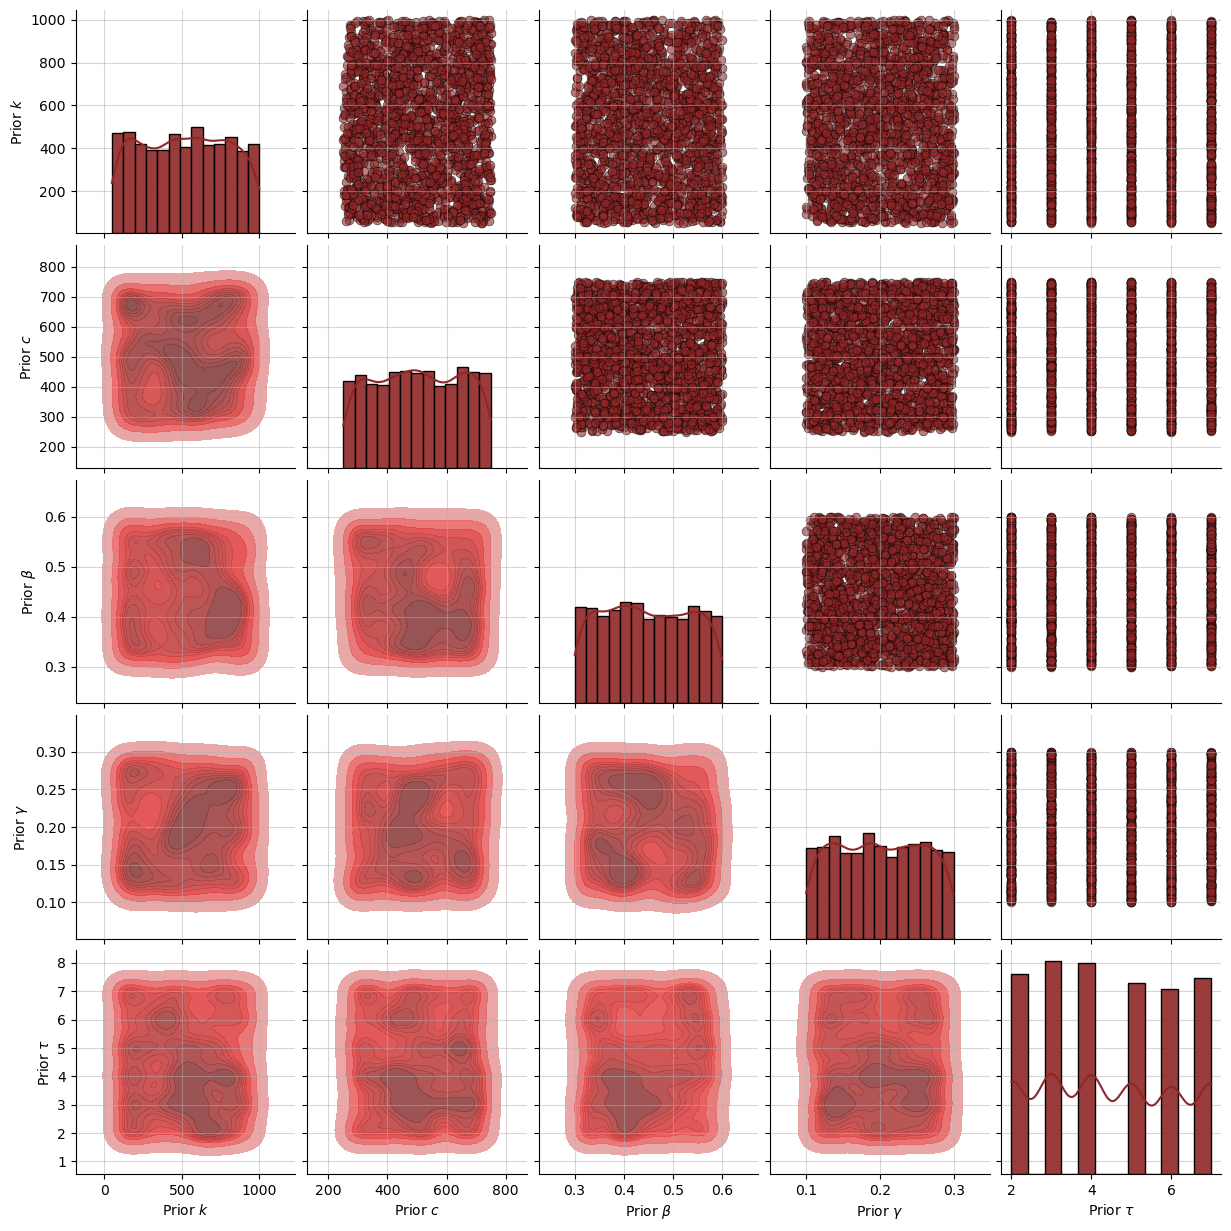

In [12]:
# As per default, the plot_prior2d function will obtain 1000 draws from the joint prior.
f = prior.plot_prior2d()

## Defining the Neural Approximator <a class="anchor" id="defining_the_neural"></a>

We can now proceed to define our BayesFlow neural architecture, that is, combine a summary network with an invertible inference network.

### Summary Network <a class="anchor" id="summary_network"></a>

Since our simulator outputs 3D tensors of shape ``(batch_size, T = 14, 1)``, we need to reduce this three-dimensional tensor into a two-dimensional tensor of shape ``(batch_size, summary_dim)``. Our model outputs are actually so simple that we could have just removed the trailing dimension of the raw outputs and simply fed the data directly to the inference network.

However, for the purpose of illustration (and generalization), we will create a more elaborate summary network consisting of 1D convolutional layers (https://peltarion.com/knowledge-center/documentation/modeling-view/build-an-ai-model/blocks/1d-convolution) followed by a Long Short-Term Memory (LSTM) network (https://colah.github.io/posts/2015-08-Understanding-LSTMs/). Such an architecture not only does what we want, but also generalizes to much more complex models and longer time-series of varying time steps, see for instance our ``OutbreakFlow`` architecture:

https://arxiv.org/abs/2010.00300

Feel free to experiment with different summary architectures as well!

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
COUPLING_NET_SETTINGS = {
    #"dense_args": dict(units=128, kernel_regularizer=None, activation="relu"),
    "num_dense": 2,
    "dropout_prob": 0.2, "bins" : 32
}
 
summary_net = SequenceNetwork(summary_dim=32,lstm_units=128,bidirectional=False)#,summary_dim = 32)


class CustomLSTM(tf.keras.Model):
    def __init__(self, hidden_size=128, summary_dim=32):
        super().__init__()
        self.LSTM = tf.keras.Sequential(
            [
                layers.LSTM(64, return_sequences=True),
                layers.LSTM(32),  # returns last output (no sequences)
                layers.Dense(32, activation='relu'),
                tf.keras.layers.Dense(summary_dim, activation="elu"),
            ]
        )

    def call(self, x, **kwargs):
        out = self.LSTM(x)
        return out
summary_net = summary_net

### Inference Network <a class="anchor" id="inference_network"></a>


In [14]:
inference_net = InvertibleNetwork(num_params=len(prior.param_names), num_coupling_layers=4, coupling_settings=COUPLING_NET_SETTINGS)#,coupling_design ='spline')

### Amortized Posterior <a class="anchor" id="amortized_posterior"></a>

We can now connect the summary and inference networks via the `AmortizedPosterior` wrapper:

In [15]:
amortizer = AmortizedPosterior(inference_net, summary_net, name="covid_amortizer")

Note, that the `name` keyword argument is optional, but it is good practice to name your models and amortizers.

In other words, we need to ensure the outputs of the forward model are suitable for processing with neural networks. Currently, they are not, since our data $\boldsymbol{x}_{1:T}$ consists of large integer (count) values. However, neural networks like scaled data. Furthermore, our parameters $\boldsymbol{\theta}$ exhibit widely different scales due to their prior specification and role in the simulator, so we will standardize them using our previously computed prior means and standard deviations. In addition, ODE models are prone to divergences and exploding outputs, which will mess up our training. In sum, our configurator does the following:

1. Initializes a new dictionary (line 7).
2. Performs a log-transform on the simulated data and convert it to `float32` type (line 10).
3. Converts the prior draws to `float32` type and standardizes them (lines 13 - 14).
4. Removes potentially problematic simulations from the batch (lines 17 - 19).

In [16]:
# Recalculamos las medias y desviaciones estándar del prior
prior_means, prior_stds = prior.estimate_means_and_stds()

print(prior_means)
print(prior_stds)
def configure_input(forward_dict):
    """Function to configure the simulated quantities (i.e., simulator outputs)
    into a neural network-friendly (BayesFlow) format.
    """

    # Prepare placeholder dict
    out_dict = {}

    # Convert data to logscale
    logdata = forward_dict["sim_data"]#np.log1p(forward_dict["sim_data"]).astype(np.float32)

    # Extract prior draws and z-standardize with previously computed means
    params = forward_dict["prior_draws"].astype(np.float32)
    #params = (params - prior_means) / prior_stds

    # Remove a batch if it contains nan, inf or -inf
    idx_keep = np.all(np.isfinite(logdata), axis=(1, 2))
    if not np.all(idx_keep):
        print("Invalid value encountered...removing from batch")

    # Add to keys
    out_dict["summary_conditions"] = logdata[idx_keep]
    out_dict["parameters"] = params[idx_keep]

    return out_dict

[[5.18458000e+02 4.96604034e+02 4.50384321e-01 1.99389951e-01
  4.52400000e+00]]
[[2.73394024e+02 1.43349638e+02 8.64308612e-02 5.91127790e-02
  1.66679399e+00]]


## Defining the Trainer <a class="anchor" id="defining_the_trainer"></a>

Finally, we are in a position to define our `Trainer` instance. Notice that we also pass out custom `configurator` function to the constructer. The default configurator won't do in this case!

Note, that you should supply a `checkpoint_path` for the `Trainer` instance, if you don't want to save the neural approximators manually! Note also, that we are using `memory=True` so that the trainer keeps some simulations encountered during training. After training, we can quickly perform some diagnostics on these "remembered" simulations to judge the convergence quality.

In [17]:
trainer = Trainer(amortizer=amortizer, generative_model=model, configurator=configure_input, memory=True)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Great, the trainer informs us that the consistency check (i.e., simulation -> configuration -> transformation -> loss computation) was successful. We can now train our networks on epidemiological simulations. We can also check out the number of trainable neural network parameters for the composite approximator:

In [18]:
amortizer.summary()

Model: "covid_amortizer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network (Invert  multiple                  342136    
 ibleNetwork)                                                    
                                                                 
 sequence_network (Sequence  multiple                  94016     
 Network)                                                        
                                                                 
Total params: 436152 (1.66 MB)
Trainable params: 436112 (1.66 MB)
Non-trainable params: 40 (160.00 Byte)
_________________________________________________________________


## Training Phase <a class="anchor" id="training_phase"></a>

Ready to train! Since our simulator is pretty fast, we can safely go with online training. Let's glean the time taken for a batch of $32$ simulations:

In [19]:
%%time
offline_data = model(128000)

CPU times: total: 1min 26s
Wall time: 1min 56s


Still, for the purpose of this illustration, we will use offline training on as little as $10000$ simulated data sets.

In [20]:
%%time
history = trainer.train_offline(offline_data, epochs=25,   batch_size=32, validation_sims=100,early_stopping=True)#100 epochs

INFO:root:Generated 100 simulations for validation.


Training epoch 1:   0%|          | 0/4000 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 9.298


Training epoch 2:   0%|          | 0/4000 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 7.979


...

Training epoch 24:   0%|          | 0/4000 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 24, Loss: 2.049


Training epoch 25:   0%|          | 0/4000 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 25, Loss: 2.059


CPU times: total: 2h 6min 31s
Wall time: 2h 22min 58s


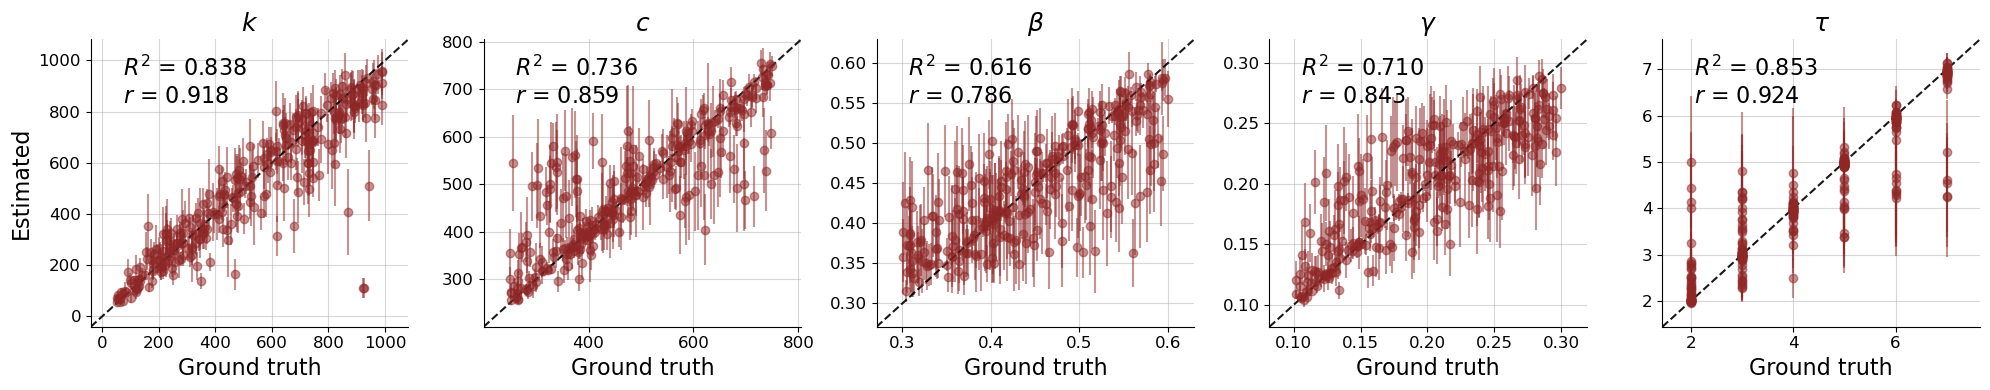

In [35]:
validation_sims = trainer.configurator(model(batch_size=300))
post_samples = amortizer.sample(validation_sims, n_samples=1000)
f = diag.plot_recovery(post_samples, validation_sims["parameters"], param_names=prior.param_names)# 32 batch size, 32 lstm

In [36]:
from scipy.stats import nbinom

def SIR_with_behavior_I0(params, T,N,I0, eps=1e-5):
    """Simula el modelo SIR con k y c."""
    k,c,beta,gamma,tau = params
    c=c/100000
    #print(I0)
    # Redondea I0 para que sea un entero
    # Condiciones iniciales
    S, I, R = [N - I0], [I0], [0]
    I_t_tau  = np.repeat(I0,np.round(tau))
    # Simulamos T pasos de tiempo
    for t in range(T-1):
        # Valores actuales
        S_t, I_t, R_t = S[-1], I[-1], R[-1]

        

        # Calcular r(I(t)) 
        # usando una sigmoide estable
        x = k * (I_t_tau[t]/N - c)
        r_I = expit(x)

        nuevas_infecciones = (1 - r_I) * beta * S_t * I_t / N

        # Ecuaciones SIR
        dS = -nuevas_infecciones
        dI = nuevas_infecciones - gamma * I_t
        dR = gamma * I_t
  
        # Actualizamos las variables
        S_next = S_t + dS
        factor = 1 + np.random.uniform(-0.2, 0.2)
        I_next = I_t + dI#*factor
        R_next = R_t + dR

        # Agregamos los nuevos valores
        S.append(S_next)
        I.append(I_next)
        R.append(R_next)
        I_t_tau=np.append(I_t_tau,I_next)
    I_array = np.array(I)[:, np.newaxis]
    return I_array

Depending on your machine, offline training for $30$ epochs should take between $1$ and $3$ minutes. In practice, you should train for a longer number of epochs ($100$ is a good starting heuristic).

### Inspecting the Loss <a class="anchor" id="inspecting_the_loss"></a>

Following our online simulation-based training, we can quickly visualize the loss trajectory using the `plot_losses` function from the `diagnostics` module.

In [23]:
#f = diag.plot_losses(history["train_losses"], history["val_losses"], moving_average=True)

Great, it seems that our approximator has converged! Before we get too excited and throw our networks at real data, we need to make sure that they meet our expectations <em>in silico</em>, that is, given the small world of simulations the networks have seen.

## Validation Phase <a class="anchor" id="validation_phase"></a>


### Inspecting the Latent Space <a class="anchor" id="inspecting_the_latent"></a>

A quick and useful diagnostic is to check whether the marginal latent distribution $p(\boldsymbol{z})$ has the prescribed probabilistic structure. Since, by default, we optimize the amortizer with the Kullback-Leibler (KL) loss (also known as maximum likelihood training, which is not to be confused with maximum likelihood estimation!), we expect to observe approximately Gaussian latent space with independent axes. Moreover, since the trainer also keeps an internal `SimulationMemory` instance, we can also directly call it's `diagnose_latent2d` method (also available in the `diagnostics` module):

In [24]:
#f = trainer.diagnose_latent2d()

### Simulation-Based Calibration - Rank Histograms <a class="anchor" id="simulation_based_calibration__"></a>

As a further <strong>small world</strong> (i.e., before real data) sanity check, we can also test the calibration of the amortizer through simulation-based calibration (SBC). See the corresponding paper by Sean Talts, Michael Betancourt, Daniel Simpson, Aki Vehtari, and Andrew Gelman for more details:

https://arxiv.org/pdf/1804.06788.pdf

Accordingly, we expect to observe approximately uniform rank statistic histograms.

In [25]:
#f = trainer.diagnose_sbc_histograms()

### Simulation-Based Calibration - Rank ECDF <a class="anchor" id="simulation_based_calibration___0"></a>

For models with many parameters, inspecting many histograms can become unwieldly. Moreover, the `num_bins` hyperparameter for the construction of SBC rank histograms can be hard to choose. An alternative diagnostic approach for calibration is through empirical cumulative distribution functions (ECDF) of rank statistics. You can read more about this approach in the corresponding paper by Teemu Säilynoja, Paul-Christian Bürkner, and Aki Vehtari:

https://arxiv.org/abs/2103.10522

In order to inspect the ECDFs of marginal distributions, we will simulate $300$ new pairs of simulated data and generating parameters $(\boldsymbol{x}, \boldsymbol{\theta})$ and use the function `plot_sbc_ecdf` from the `diagnostics` module: 

In [26]:
# # Generate some validation data
# validation_sims = trainer.configurator(model(batch_size=300))

# # Generate posterior draws for all simulations
# post_samples = amortizer.sample(validation_sims, n_samples=100)

In [27]:
# # Create ECDF plot
# f = diag.plot_sbc_ecdf(post_samples, validation_sims["parameters"], param_names=prior.param_names)

We can also produce stacked ECDFs and compute ECDF differences for a more dynamic visualization range.

In [28]:
# f = diag.plot_sbc_ecdf(
#     post_samples, validation_sims["parameters"], stacked=True, difference=True, legend_fontsize=12, fig_size=(6, 5)
# )

Fianlly, we can also compute SBC histograms on the new validation data by calling the function `plot_sbc_histograms` directly.

In [29]:
# f = diag.plot_sbc_histograms(post_samples, validation_sims["parameters"], param_names=prior.param_names)

## Inferential Adequacy (Global) <a class="anchor" id="inferential_adequacy__global_"></a>

Depending on the application, it might be interesting to see how well summaries of the full posterior (e.g., means, medians) recover the assumed true parameter values. We can test this <em>in silico</em> via the `plot_recovery` function in the `diagnostics` module. For instance, we can compare how well posterior means recover the true parameter (i.e., posterior z-score, https://betanalpha.github.io/assets/case_studies/principled_bayesian_workflow.html). Below, we re-use the $300$ simulations we took for computing the rank ECDFs, but obtain a larger number of posterior draws per data set for more stable results:

In [30]:
# validation_sims = trainer.configurator(model(batch_size=300))
# #validation_sims = model(batch_size=300)
# post_samples = amortizer.sample(validation_sims, n_samples=1000)
# f = diag.plot_recovery(post_samples, validation_sims["parameters"], param_names=prior.param_names)# 32 batch size, 32 lstm

## Inference Phase <a class="anchor" id="inference_phase"></a>

We can now move on to using real data. As an important general remark: remember that the real and simulated data need to be in the same format (i.e., discrete indicators should be one-hot-encoded, transformations during training should also be applied during inference, etc.).

### Bivariate Posteriors <a class="anchor" id="bivariate_posteriors"></a>

Finally, we can feed the real case data from the first two weeks and inspect the approximate posteriors or obtain model-based predictions.

In [37]:
IS = SIR_with_behavior_I0([500, 0.005*100000, 0.6, 0.2, 5], 50,1000000,1250, eps=1e-5)

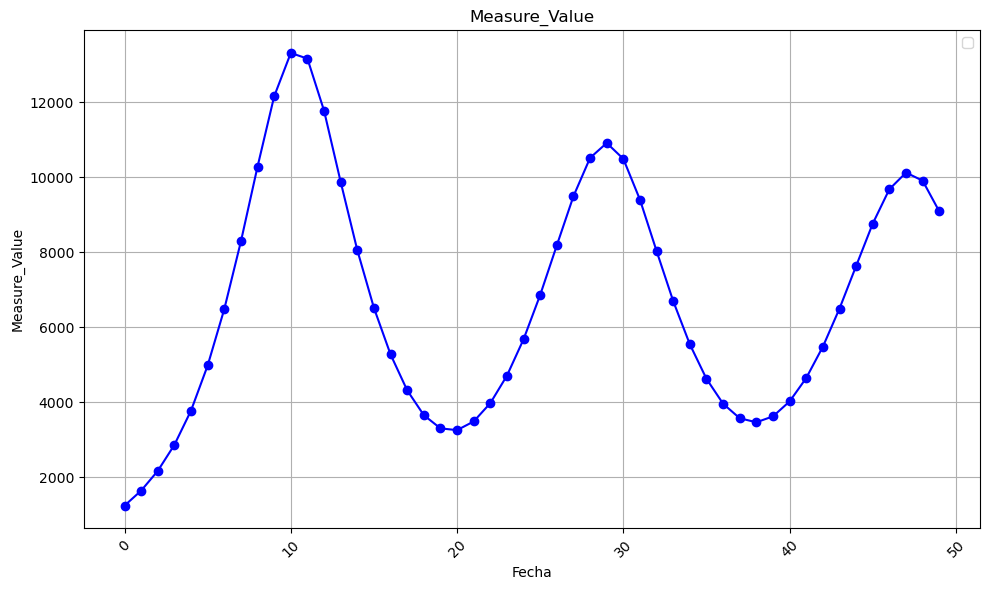

In [38]:

diccionario=model(batch_size=1)
diccionario['sim_data'][0]=IS
diccionario_transformado= configure_input(diccionario)
config["obs_data"] = IS
#config["obs_data"] = diccionario['sim_data'][0]







# Crear una columna de fecha combinando YEAR y WEEK
df = pd.DataFrame(IS)
df.columns = ['I']
df['ids'] = range(len(df))
# Graficar la variable TOTAL B
plt.figure(figsize=(10, 6))
plt.plot(df['ids'], df['I'], marker='o', color='b', label='')
plt.xlabel('Fecha')
plt.ylabel('Measure_Value')
plt.title('Measure_Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Obtain 500 posterior draws given real data
post_samples = amortizer.sample(diccionario_transformado, 5000)

# Undo standardization to get parameters on their original (unstandardized) scales
#post_samples = prior_means + post_samples * prior_stds
post_samples.mean(axis=0)

array([5.0671320e+02, 5.2335504e+02, 5.8489299e-01, 1.9655395e-01,
       4.8900833e+00], dtype=float32)

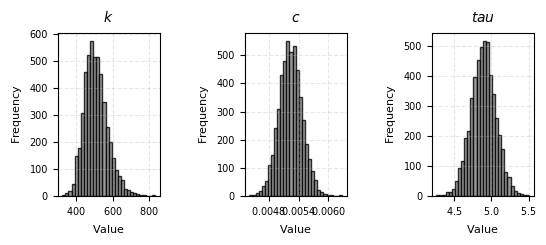

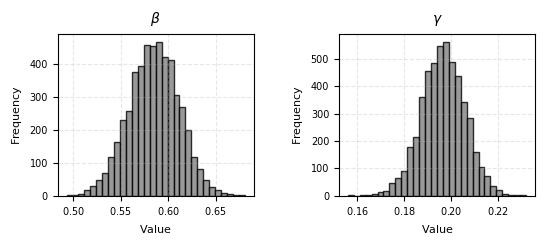

In [57]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator

# Extraemos los parámetros
param_k = post_samples[:, 0]
param_c = post_samples[:, 1]/100000
param_tau = post_samples[:, 4]

param_beta = post_samples[:, 2]
param_gamma = post_samples[:, 3]

# --- FIGURA 1: k, c, tau ---
fig1, axs1 = plt.subplots(1, 3, figsize=(6, 3))

params1 = [param_k, param_c,param_tau]
titles1 = [r"$k$", r"$c$",r"$tau$"]

for ax, data, title in zip(axs1, params1, titles1):
    ax.hist(data, bins=30, color='gray', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel(r"$\mathrm{Value}$", fontsize=8) 
    ax.set_ylabel(r"$\mathrm{Frequency}$", fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.offsetText.set_fontsize(7)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# 🔧 Controlar número de ticks del eje X de c
axs1[1].xaxis.set_major_locator(MaxNLocator(nbins=4))  # solo 4 valores de x
axs1[1].xaxis.get_offset_text().set_fontsize(7)

fig1.tight_layout(pad=1.5)
plt.show()


# --- FIGURA 2: beta, gamma ---
fig2, axs2 = plt.subplots(1, 2, figsize=(6, 3))

params2 = [param_beta, param_gamma]
titles2 = [r"$\beta$", r"$\gamma$"]

for ax, data, title in zip(axs2, params2, titles2):
    ax.hist(data, bins=30, color='gray', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel(r"$\mathrm{Value}$", fontsize=8) 
    ax.set_ylabel(r"$\mathrm{Frequency}$", fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=7)
    ax.xaxis.offsetText.set_fontsize(7)
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))

fig2.tight_layout(pad=1.5)
plt.show()



#### Standalone <a class="anchor" id="standalone"></a>

Using the `plot_posterior_2d` function from the `diagnostics` module, we can look at the bivariate posteriors in isolation:

In [ ]:
# f = diag.plot_posterior_2d(post_samples, param_names=prior.param_names)

#### Compared to Prior <a class="anchor" id="compared_to_prior"></a>

In addition, we can have a more informative plot which indicates the Bayesian surprise (i.e., difference between prior and posterior) by also supplying the prior object to the function:

In [ ]:
# f = diag.plot_posterior_2d(post_samples, prior=prior)

### Posterior Retrodictive Checks <a class="anchor" id="posterior_retrodictive_checks"></a>

These are also called <em>posterior predictive checks</em>, but here we want to explicitly highlight the fact that we are not predicting future data but testing the <strong>generative performance</strong> or <strong>re-simulation performance</strong> of the model. In other words, we want to test how well the simulator can reproduce the actually observed data given the parameter posterior $p(\boldsymbol{\theta} | \boldsymbol{x}_{1:T})$. 

Here, we will create a custom function which plots the observed data and then overlays draws from the posterior predictive.

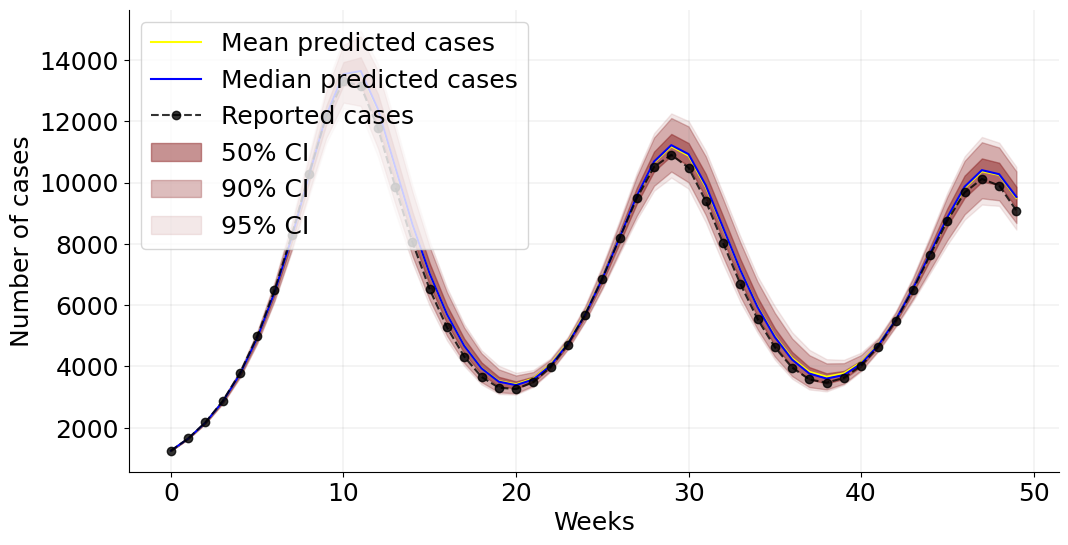

In [58]:
import matplotlib.pyplot as plt


def plot_ppc(config, post_samples, logscale=False, color="#8f2727", dummy=True, figsize=(12, 6), font_size=18):
    """
    Helper function to perform some plotting of the posterior predictive.
    """
    # Plot settings
    plt.rcParams["font.size"] = font_size

    # Remove parameters < 0
    #samples = post_samples[np.sum(post_samples < 0, axis=1) == 0]
    
    f, ax = plt.subplots(1, 1, figsize=figsize)
    samples=post_samples
    #samples = samples[samples[:,0]>1]
    # Re-simulations
    sims = []
    for i in range(samples.shape[0]):
        # Note - simulator returns 2D arrays of shape (T, 1), so we remove trailing dim
        k1,c1,beta1,gamma1,tau1 = samples[i]
        sim_cases = SIR_with_behavior_I0([k1, c1,beta1,gamma1,tau1], N=config["N"], T=config["T"],I0=config["obs_data"][0])[:, 0]
        sims.append(sim_cases)
    sims = np.array(sims)
    # Compute quantiles for each t = 1,...,T
    qs_50 = np.quantile(sims, q=[0.25, 0.75], axis=0)
    qs_90 = np.quantile(sims, q=[0.05, 0.95], axis=0)
    qs_95 = np.quantile(sims, q=[0.025, 0.975], axis=0)

    # Plot median predictions and observed data
    ax.plot(np.mean(sims, axis=0), label="Mean predicted cases", color='yellow')
    ax.plot(np.median(sims, axis=0), label="Median predicted cases", color='blue')
    ax.plot(config["obs_data"], marker="o", label="Reported cases", color="black", linestyle="dashed", alpha=0.8)

    # Add compatibility intervals (also called credible intervals)
    ax.fill_between(range(config["T"]), qs_50[0].reshape(-1), qs_50[1].reshape(-1), color=color, alpha=0.5, label="50% CI")
    ax.fill_between(range(config["T"]), qs_90[0].reshape(-1), qs_90[1].reshape(-1), color=color, alpha=0.3, label="90% CI")
    ax.fill_between(range(config["T"]), qs_95[0].reshape(-1), qs_95[1].reshape(-1), color=color, alpha=0.1, label="95% CI")

    # Grid and schmuck
    #ax.set_title("Posterior Predictive Check 2022-2023 Season")
    ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.5)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Number of cases")
    ax.minorticks_off()
    if logscale:
        ax.set_yscale("log")
    ax.legend(fontsize=font_size)
    plt.show()
    return sims

f = plot_ppc(config,post_samples)